In [ ]:
!pip install torch torchvision matplotlib numpy

### Import necessary Libraries

In [ ]:
import torch #loads the main PyTorch package.
import torch.nn as nn #loads the main PyTorch package.
import torch.optim as optim #imports optimizers such as Adam
from torchvision import datasets, transforms #gives access to common datasets (MNIST) and image transforms.
from torch.utils.data import dataloader # load the mnist datasets
import matplotlib.pyplot as plt
import numpy as np


## Encoder class
- Which maps input to the latent space

In [ ]:
class Encoder(nn.Module): #defines the encoder network.
    def __init__(self, input_dim, hidden_dim, latent_dim):
        """
        Initialize the Encoder class
        Args:

        input_dim: dimension of the input data
        hidden_dim: dimension of the hidden layer
        latent_dim: Dimension of the latent space
        """

        super(Encoder, self).__init__()

        #Define the fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden_dim) #is a fully connected layer mapping input to hidden features.
        self.fc_mu = nn.Linear(hidden_dim, latent_dim) #outputs the latent mean vector mu.
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) #outputs the latent log variance vector logvar.

    # Define the forward pass through the Encoder
    def forward(self, x):
        """
        Define the forward pass through the Encoder
        #forward: apply ReLU to hidden layer, then compute mu and logvar. Returning both lets the VAE sample a latent vector using the reparameterization trick.
        Args:
        x: input data

        Returns:
        mu: the mean of the latent space.
        logvar: the log of the latent space
         """

        # apply ReLU activation to the hidden layers
        h = torch.relu(self.fc1(x))

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        return mu, logvar

        # Latent space only storing mu and logvar

### Define the decoder class
- It maps the latent space to output.

In [ ]:
class Decoder(nn.Module): # class Decoder maps latent vectors back to input space.
    def __init__(self, latent_dim, hidden_dim, output_dim):
        """
        Initialize the decoder class
        Args:
        latent_dim: dimension of the latent space
        hidden_dim: dimension of the hidden layer
        output_dim: dimension of the output layer
        """

        super(Decoder, self).__init__()
        #Define the fully connected layers for decoder

        self.fc1 = nn.Linear(latent_dim, hidden_dim) #expands latent vector to hidden dimension.
        self.fc2 = nn.Linear(hidden_dim, output_dim) #maps hidden features to reconstructed input dimension.

    # define the forward pass through the decoder
    def forward(self, z):
        """
        Define the forward pass through the decoder
        Args:
        Z: the latent space data.
        Returns:
        z_hat: it is the reconstructed output data.
        """

        # apply relu activation to the hidden layer
        h = torch.relu(self.fc1(z))

        # apply sigmoid to the output layer because the output range is 0-9

        x_hat = torch.sigmoid(self.fc2(h))

        return x_hat # [0-9]

### Connect all the code

In [ ]:
# Define the variational autoencoder VAE Class

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        """
        Initialize the VAE Class
        Args:
        input_dim: dimension of the input data
        hidden_dim: dimension of hidden layer
        latent_dim: dimension of latent space
        """

        super(VAE, self).__init__()

        #Define the Encoder and decoder instances
        self.encoder = Encoder(input_dim = input_dim, hidden_dim = hidden_dim, latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim, hidden_dim = hidden_dim, output_dim=input_dim)

    def forward(self, x):
        """Define the forward pass through the VAE.

        Args:
        x: input data

        Returns:
        x_hat: the reconstructed output data.
        mu: the mean of the latent space.
        logvar: the log variance of the latent space.
        """

        # Encode the input of the latent space

        mu, logvar = self.encoder(x)

        # sample from latent space using reparaterization trick

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        z = mu + eps*std

        x_hat = self.decoder(z)

        return x_hat, mu, logvar

## Loss Function


In [ ]:
def loss_function(x, x_hat, mu, logvar):
    """
    Define the loss function for the VAE

    Args:
    X: Input data
    X_hat: the reconstructed output data.
    mu: the mean of the latent space.
    logvar: the logvarince of the latent space

    Returns:

    loss: the VAE Loss
    """


    #Calculate  binary cross-entropy loss
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction = 'sum')

    # calculate KL = kullback-leibler divergence loss
    KLD = -0.5 * torch.sum(1+logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

In [ ]:
input_dim = 784
hidden_layer = 400
latent_dim = 20


lr = 1e-3

batch_size = 128

epochs = 15

# dataloade

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transform)
train_loader = dataloader.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


## Define Model, Optimizer

In [ ]:
vae = VAE(input_dim=input_dim, hidden_dim=hidden_layer, latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)

# Training loop
for epoch in range(epochs):
    train_loss = 0  # Initialize train_loss for each epoch
    for x, _ in train_loader:
        # converting image to 784 length array
        x = x.view(-1, input_dim)

        # resetting the optimizer
        optimizer.zero_grad()

        # forward pass
        x_hat, mu, logvar = vae(x)

        # (you’ll need to add loss calculation and backward pass here)
        # loss = ...
        loss = loss_function(x, x_hat, mu, logvar)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(f"Epch {epoch+1}, Loss: {train_loss/len(train_loader.dataset)}")
        # loss.backward()
        # optimizer.step()

Epch 1, Loss: 163.73884262695313
Epch 2, Loss: 121.08897151692709
Epch 3, Loss: 114.23458364257813
Epch 4, Loss: 111.27712667643229
Epch 5, Loss: 109.65140581054688
Epch 6, Loss: 108.56714485677084
Epch 7, Loss: 107.73615056966146
Epch 8, Loss: 107.13361170247396
Epch 9, Loss: 106.67889542643229
Epch 10, Loss: 106.25084002278646
Epch 11, Loss: 105.92731959635417
Epch 12, Loss: 105.60028697916667
Epch 13, Loss: 105.38383881835938
Epch 14, Loss: 105.16644339192709
Epch 15, Loss: 104.96373546549479


### Testing and Evaluating the model

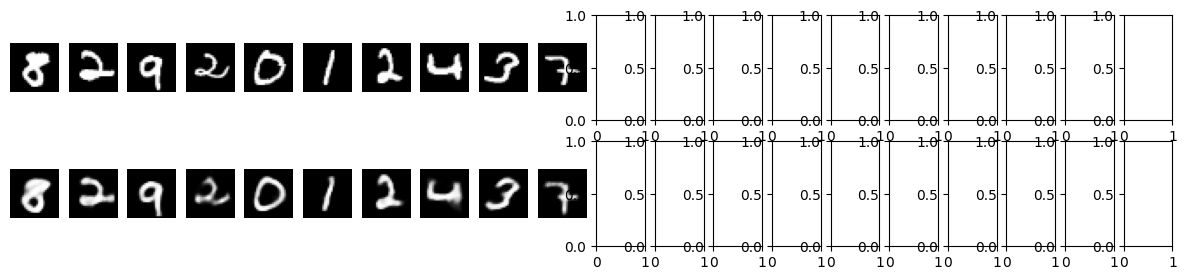

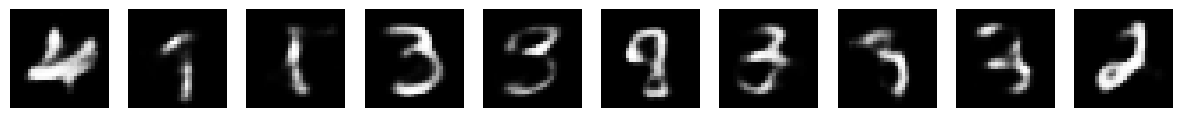

In [ ]:
vae.eval()

# reconstruction of the input data

with torch.no_grad():
    x, _ = next(iter(train_loader))

    x = x.view(-1, input_dim) # (-1, 784)

    x_hat, _, _ = vae(x)

    x = x.view(-1, 28, 28)

    x_hat = x_hat.view(-1, 28, 28)

    fig, axs = plt.subplots(2, 20, figsize = (15, 3))

    for i in range(10):
        axs[0, i].imshow(x[i].cpu().numpy(), cmap = 'gray')
        axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap = 'gray')
        axs[0,i].axis('off')
        axs[1, i].axis('off')

    plt.show()


    with torch.no_grad():
        z = torch.randn(10, latent_dim)

        newly_generated_sample = vae.decoder(z)
        newly_generated_sample_image = newly_generated_sample.view(-1, 28, 28)


        fig, axs = plt.subplots(1, 10, figsize = (15, 3))
        for i in range (10):
            axs[i].imshow(newly_generated_sample_image[i].cpu().numpy(), cmap = 'gray')

            axs[i].axis("off")
    # Visualizing newly generated data

    # Generative AI Part of the demo

- first one is input and second one is recostructed output.
- Visualizing newly generated data
- Generative AI Part iof the demo